# Phishing Detection System


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

%matplotlib inline

## 2. Load Data


In [2]:
df = pd.read_csv("C:/Users/DCL/Downloads/Dataset/phishing_site_urls.csv")
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


## 3. Text Preprocessing


In [3]:
df.shape

(1048572, 2)

In [4]:
df.isnull().sum()

URL      0
Label    0
dtype: int64

In [5]:
df.Label.value_counts()

Label
good    667182
bad     381389
bad          1
Name: count, dtype: int64

In [6]:
df['Label'] = df['Label'].str.strip().str.lower()
df.Label.value_counts()

Label
good    667182
bad     381390
Name: count, dtype: int64

In [7]:
label_counts_per_url = df.groupby('URL')['Label'].nunique()
contradictory_urls = label_counts_per_url[label_counts_per_url > 1].index

before = len(df)
df = df[~df['URL'].isin(contradictory_urls)].drop_duplicates('URL').reset_index(drop=True)
after = len(df)

print(f"Removed {before - after:,} rows ({100*(before-after)/before:.1f}%) with contradictory or duplicate labels.")
print(f"Remaining clean rows: {after:,}")
df.Label.value_counts()

Removed 442,174 rows (42.2%) with contradictory or duplicate labels.
Remaining clean rows: 606,398


Label
good    371110
bad     235288
Name: count, dtype: int64

In [8]:
!pip install nltk



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from nltk.tokenize import RegexpTokenizer

In [10]:
tokenizer = RegexpTokenizer(r'[A-Za-z]+')
df.URL[0]
tokenizer.tokenize(df.URL[0])

['Y',
 'e',
 'b',
 'm',
 'I',
 'X',
 'jw',
 'D',
 'gM',
 'GN',
 'L',
 'F',
 'C',
 'Z',
 'M',
 'J',
 'H',
 'f',
 'i',
 'd']

In [11]:
df['text_tokenized'] = df.URL.map(lambda t: tokenizer.tokenize(t))

In [12]:
df.head()

,URL,Label,text_tokenized
0,"2#û¸þ @Y~""Áª'eb}mê½ì@éI5ÿ-ÄXå¦¢Ê%jw°...",good,"[Y, e, b, m, I, X, jw, D, gM, GN, L, F, C, Z, ..."
1,CYplhZyÏ.ûüH¡¨ÑËEg+=ùòõgáN{;¥Ö ÃèÕf÷)e A,good,"[CY, p, lhZy, H, Eg, g, N, f, e, A]"
2,diaryofagameaddict.com,bad,"[diaryofagameaddict, com]"
3,espdesign.com.au,bad,"[espdesign, com, au]"
4,iamagameaddict.com,bad,"[iamagameaddict, com]"


In [13]:
from nltk. stem. snowball import SnowballStemmer
stemmer = SnowballStemmer('english')

In [14]:
df['text_stemmed' ] = df['text_tokenized'].map(lambda l: [stemmer.stem(word) for word in l])

In [15]:
df.head()

,URL,Label,text_tokenized,text_stemmed
0,"2#û¸þ @Y~""Áª'eb}mê½ì@éI5ÿ-ÄXå¦¢Ê%jw°...",good,"[Y, e, b, m, I, X, jw, D, gM, GN, L, F, C, Z, ...","[y, e, b, m, i, x, jw, d, gm, gn, l, f, c, z, ..."
1,CYplhZyÏ.ûüH¡¨ÑËEg+=ùòõgáN{;¥Ö ÃèÕf÷)e A,good,"[CY, p, lhZy, H, Eg, g, N, f, e, A]","[cy, p, lhzi, h, eg, g, n, f, e, a]"
2,diaryofagameaddict.com,bad,"[diaryofagameaddict, com]","[diaryofagameaddict, com]"
3,espdesign.com.au,bad,"[espdesign, com, au]","[espdesign, com, au]"
4,iamagameaddict.com,bad,"[iamagameaddict, com]","[iamagameaddict, com]"


In [16]:
df['text'] = df['text_stemmed'].map(lambda l: ' '.join(l))

In [17]:
df.head()

,URL,Label,text_tokenized,text_stemmed,text
0,"2#û¸þ @Y~""Áª'eb}mê½ì@éI5ÿ-ÄXå¦¢Ê%jw°...",good,"[Y, e, b, m, I, X, jw, D, gM, GN, L, F, C, Z, ...","[y, e, b, m, i, x, jw, d, gm, gn, l, f, c, z, ...",y e b m i x jw d gm gn l f c z m j h f i d
1,CYplhZyÏ.ûüH¡¨ÑËEg+=ùòõgáN{;¥Ö ÃèÕf÷)e A,good,"[CY, p, lhZy, H, Eg, g, N, f, e, A]","[cy, p, lhzi, h, eg, g, n, f, e, a]",cy p lhzi h eg g n f e a
2,diaryofagameaddict.com,bad,"[diaryofagameaddict, com]","[diaryofagameaddict, com]",diaryofagameaddict com
3,espdesign.com.au,bad,"[espdesign, com, au]","[espdesign, com, au]",espdesign com au
4,iamagameaddict.com,bad,"[iamagameaddict, com]","[iamagameaddict, com]",iamagameaddict com


In [18]:
good_sites = df[df.Label == 'good']
bad_sites = df[df.Label == 'bad']

In [19]:
good_sites.head()

,URL,Label,text_tokenized,text_stemmed,text
0,"2#û¸þ @Y~""Áª'eb}mê½ì@éI5ÿ-ÄXå¦¢Ê%jw°...",good,"[Y, e, b, m, I, X, jw, D, gM, GN, L, F, C, Z, ...","[y, e, b, m, i, x, jw, d, gm, gn, l, f, c, z, ...",y e b m i x jw d gm gn l f c z m j h f i d
1,CYplhZyÏ.ûüH¡¨ÑËEg+=ùòõgáN{;¥Ö ÃèÕf÷)e A,good,"[CY, p, lhZy, H, Eg, g, N, f, e, A]","[cy, p, lhzi, h, eg, g, n, f, e, a]",cy p lhzi h eg g n f e a
36995,01453.com/,good,[com],[com],com
36996,015fb31.netsolhost.com/bosstweed.html,good,"[fb, netsolhost, com, bosstweed, html]","[fb, netsolhost, com, bosstwe, html]",fb netsolhost com bosstwe html
36997,02bee66.netsolhost.com/lincolnhomepage/,good,"[bee, netsolhost, com, lincolnhomepage]","[bee, netsolhost, com, lincolnhomepag]",bee netsolhost com lincolnhomepag


In [20]:
bad_sites.head()

,URL,Label,text_tokenized,text_stemmed,text
2,diaryofagameaddict.com,bad,"[diaryofagameaddict, com]","[diaryofagameaddict, com]",diaryofagameaddict com
3,espdesign.com.au,bad,"[espdesign, com, au]","[espdesign, com, au]",espdesign com au
4,iamagameaddict.com,bad,"[iamagameaddict, com]","[iamagameaddict, com]",iamagameaddict com
5,kalantzis.net,bad,"[kalantzis, net]","[kalantzi, net]",kalantzi net
6,slightlyoffcenter.net,bad,"[slightlyoffcenter, net]","[slightlyoffcent, net]",slightlyoffcent net


In [21]:
from wordcloud import STOPWORDS, WordCloud, ImageColorGenerator

def plot_wordcloud(text, mask=None, max_words=400, max_font_size=120, figure_size=(24.0,16.0),
                    title = None, title_size=40, image_color=False):
    stopwords = set(STOPWORDS)
    more_stopwords = {'com','http'}
    stopwords = stopwords.union(more_stopwords)

    wordcloud = WordCloud(background_color='white',
                    stopwords = stopwords,
                    max_words = max_words,
                    max_font_size = max_font_size,
                    random_state = 42,
                    mask = mask)
    wordcloud.generate(text)

    plt.figure(figsize=figure_size)
    if image_color:
        image_colors = ImageColorGenerator(mask);
        plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear");
        plt.title(title, fontdict={'size': title_size,
                                    'verticalalignment': 'bottom'})

    else:
        plt.imshow(wordcloud);
        plt.title(title, fontdict={'size': title_size, 'color': 'green',
                                    'verticalalignment': 'bottom'})

        plt.axis('off');
        plt.tight_layout()

In [22]:
all_text = ''.join(good_sites['text'].tolist())

In [23]:
from wordcloud import WordCloud

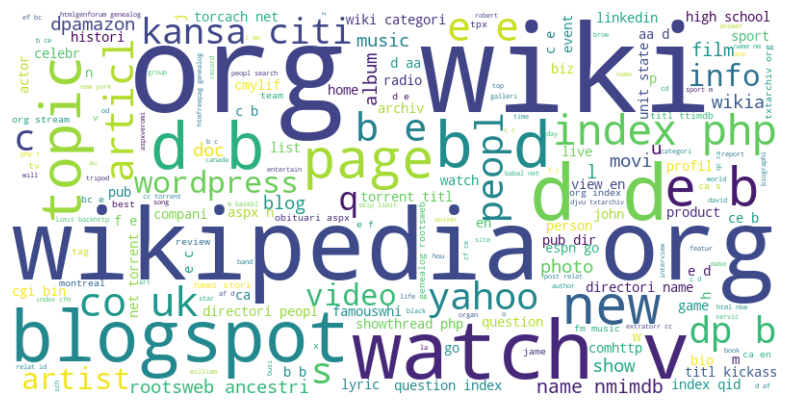

In [24]:
# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [25]:
all_text= ' '.join(bad_sites['text'].tolist())

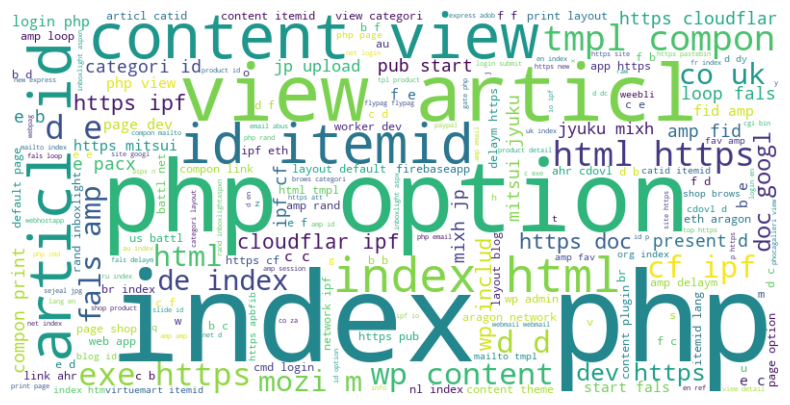

In [26]:
# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [27]:
df.head()

,URL,Label,text_tokenized,text_stemmed,text
0,"2#û¸þ @Y~""Áª'eb}mê½ì@éI5ÿ-ÄXå¦¢Ê%jw°...",good,"[Y, e, b, m, I, X, jw, D, gM, GN, L, F, C, Z, ...","[y, e, b, m, i, x, jw, d, gm, gn, l, f, c, z, ...",y e b m i x jw d gm gn l f c z m j h f i d
1,CYplhZyÏ.ûüH¡¨ÑËEg+=ùòõgáN{;¥Ö ÃèÕf÷)e A,good,"[CY, p, lhZy, H, Eg, g, N, f, e, A]","[cy, p, lhzi, h, eg, g, n, f, e, a]",cy p lhzi h eg g n f e a
2,diaryofagameaddict.com,bad,"[diaryofagameaddict, com]","[diaryofagameaddict, com]",diaryofagameaddict com
3,espdesign.com.au,bad,"[espdesign, com, au]","[espdesign, com, au]",espdesign com au
4,iamagameaddict.com,bad,"[iamagameaddict, com]","[iamagameaddict, com]",iamagameaddict com


## 4. Feature Extraction (CountVectorizer)

In [28]:
!python -m pip install scikit-learn


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix


In [30]:
def url_features(url: str) -> dict:
    """Handcrafted, URL-only features known to carry phishing signal."""
    url_l = url.lower()
    return {
        'length': len(url),
        'num_dots': url.count('.'),
        'num_hyphens': url.count('-'),
        'num_digits': sum(c.isdigit() for c in url),
        'num_at': url.count('@'),
        'num_slash': url.count('/'),
        'has_https': int('https' in url_l),
        'has_ip': int(bool(re.search(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', url))),
        'num_subdomains': url.split('/')[0].count('.'),
        'suspicious_words': sum(w in url_l for w in
            ['login', 'verify', 'account', 'secure', 'update', 'banking', 'confirm']),
    }

tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=3000)

def build_features(urls, fit=False):
    """Combine TF-IDF char n-grams with handcrafted URL features into one sparse matrix.
    Set fit=True only for the training data (fits tfidf); use fit=False for anything transformed
    afterwards (test data, new prediction examples) so we don't leak / refit on new data."""
    if fit:
        X_text = tfidf.fit_transform(urls)
    else:
        X_text = tfidf.transform(urls)
    feat_df = pd.DataFrame([url_features(u) for u in urls])
    return hstack([X_text, csr_matrix(feat_df.values)]).tocsr()


In [31]:
features = build_features(df.URL, fit=True)
features.shape


(606398, 3010)

In [32]:
features[:5].toarray()

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 2., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(5, 3010))

## 5. Model Training/Test Split

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
x_train, x_test, y_train, y_test = train_test_split(features, df.Label, test_size=0.2, random_state=42, stratify=df.Label)
x_train.shape, x_test.shape


((485118, 3010), (121280, 3010))

## 6. Logistic Regression

In [35]:
lr_model = LogisticRegression(max_iter=2000, C=5, random_state=42, class_weight='balanced')
lr_model.fit(x_train, y_train)


C:\Users\DCL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",5
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is

In [36]:
lr_model.score(x_test, y_test)

0.9544689973614776

In [37]:
lr_model.score(x_train, y_train)

0.9568620418125074

In [38]:
print('\nCLASSIFICATION REPORT (Logistic Regression)\n')
print(classification_report(y_test, lr_model.predict(x_test),
target_names=['Bad', 'Good']))


CLASSIFICATION REPORT (Logistic Regression)

              precision    recall  f1-score   support

         Bad       0.94      0.95      0.94     47058
        Good       0.97      0.96      0.96     74222

    accuracy                           0.95    121280
   macro avg       0.95      0.95      0.95    121280
weighted avg       0.95      0.95      0.95    121280




CONFUSION MATRIX (Logistic Regression)


<Axes: >

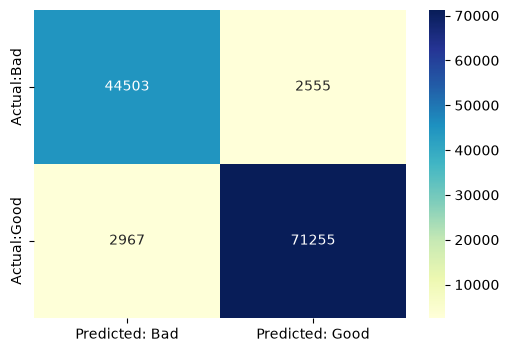

In [39]:
con_mat_lr = pd.DataFrame(confusion_matrix(y_test, lr_model.predict(x_test)),
columns=['Predicted: Bad', 'Predicted: Good'],
index=['Actual:Bad', 'Actual:Good'])

print('\nCONFUSION MATRIX (Logistic Regression)')
plt.figure(figsize=(6,4))
sns.heatmap(con_mat_lr, annot=True, fmt='d', cmap='YlGnBu')

## 7. Multinomial Naive Bayes

In [40]:
!python -m pip install seaborn


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
mnb_model = MultinomialNB()
mnb_model.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[188230.,296888.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.95,-0.49]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U4](2,)","['bad','good']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 3010)","[[ 162.32, 59.07, 14.72,..., 13215. , 94678. , 18675. ], [ 477.9 , 736.3 , 620.86,..., 89. ,356552. , 1093. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 3010)","[[-11.52,-12.52,-13.86,..., -7.12, -5.15, -6.78], [-10.65,-10.22,-10.39,...,-12.33, -4.04, -9.83]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3010


In [42]:
mnb_model.score(x_test, y_test)

0.8943848944591029

In [43]:
mnb_model.score(x_train, y_train)

0.8946503737235064

In [44]:
print('\nCLASSIFICATION REPORT (Naive Bayes)\n')
print(classification_report(y_test, mnb_model.predict(x_test),
target_names=['Bad', 'Good']))


CLASSIFICATION REPORT (Naive Bayes)

              precision    recall  f1-score   support

         Bad       0.91      0.81      0.86     47058
        Good       0.89      0.95      0.92     74222

    accuracy                           0.89    121280
   macro avg       0.90      0.88      0.89    121280
weighted avg       0.90      0.89      0.89    121280




CONFUSION MATRIX (Naive Bayes)


<Axes: >

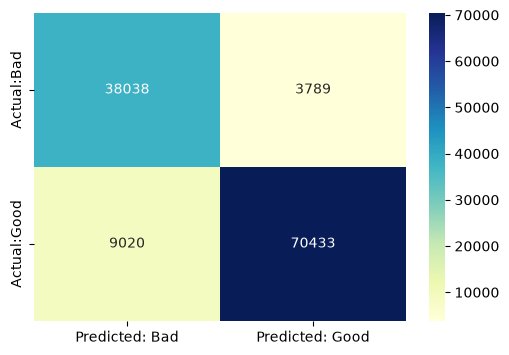

In [45]:
con_mat_mnb = pd.DataFrame(confusion_matrix(mnb_model.predict(x_test), y_test),
columns=['Predicted: Bad', 'Predicted: Good'],
index=['Actual:Bad', 'Actual:Good'])

print('\nCONFUSION MATRIX (Naive Bayes)')
plt.figure(figsize=(6,4))
sns.heatmap(con_mat_mnb, annot=True, fmt='d', cmap='YlGnBu')

## 8. Support Vector Machine (LinearSVC)


In [46]:
svm_model = LinearSVC(random_state=42, max_iter=5000, class_weight='balanced')
svm_model.fit(x_train, y_train)


,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",5000
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_

In [47]:
svm_model.score(x_test, y_test)

0.9569920844327177

In [48]:
svm_model.score(x_train, y_train)

0.9595685998045836

In [49]:
print('\nCLASSIFICATION REPORT (SVM)\n')
print(classification_report(y_test, svm_model.predict(x_test),
target_names=['Bad', 'Good']))


CLASSIFICATION REPORT (SVM)

              precision    recall  f1-score   support

         Bad       0.94      0.95      0.94     47058
        Good       0.97      0.96      0.96     74222

    accuracy                           0.96    121280
   macro avg       0.95      0.96      0.95    121280
weighted avg       0.96      0.96      0.96    121280




CONFUSION MATRIX (SVM)


<Axes: >

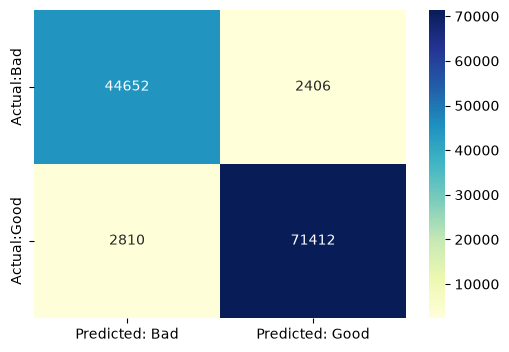

In [50]:
con_mat_svm = pd.DataFrame(confusion_matrix(y_test, svm_model.predict(x_test)),
columns=['Predicted: Bad', 'Predicted: Good'],
index=['Actual:Bad', 'Actual:Good'])

print('\nCONFUSION MATRIX (SVM)')
plt.figure(figsize=(6,4))
sns.heatmap(con_mat_svm, annot=True, fmt='d', cmap='YlGnBu')

## 9. Decision Tree Classifier

In [51]:
dt_model = DecisionTreeClassifier(max_depth=30, min_samples_split=10, min_samples_leaf=2, random_state=42, class_weight='balanced')
dt_model.fit(x_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are c

In [52]:
dt_model.score(x_test, y_test)

0.9628710422163589

In [53]:
dt_model.score(x_train, y_train)

0.9753523884910476

In [54]:
print('\nCLASSIFICATION REPORT (Decision Tree)\n')
print(classification_report(y_test, dt_model.predict(x_test),
target_names=['Bad', 'Good']))



CLASSIFICATION REPORT (Decision Tree)

              precision    recall  f1-score   support

         Bad       0.95      0.96      0.95     47058
        Good       0.97      0.97      0.97     74222

    accuracy                           0.96    121280
   macro avg       0.96      0.96      0.96    121280
weighted avg       0.96      0.96      0.96    121280




CONFUSION MATRIX (Decision Tree)


<Axes: >

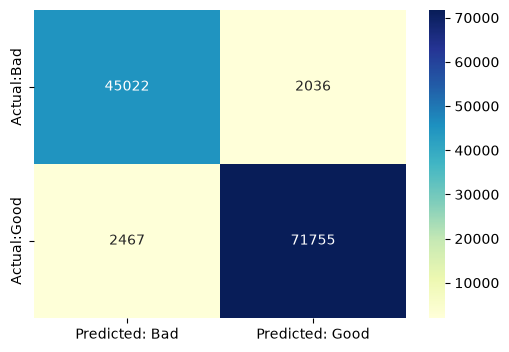

In [55]:
con_mat_dt = pd.DataFrame(confusion_matrix(y_test, dt_model.predict(x_test)),
columns=['Predicted: Bad', 'Predicted: Good'],
index=['Actual:Bad', 'Actual:Good'])

print('\nCONFUSION MATRIX (Decision Tree)')
plt.figure(figsize=(6,4))
sns.heatmap(con_mat_dt, annot=True, fmt='d', cmap='YlGnBu')


## 10. XGBoost Classifier

In [56]:
!pip install xgboost


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
neg, pos = (y_train == 'bad').sum(), (y_train == 'good').sum()
xgb_model = XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.2, random_state=42,
n_jobs=-1, eval_metric='logloss', tree_method='hist', scale_pos_weight=neg/pos)
xgb_model.fit(x_train, y_train.map({'bad': 0, 'good': 1}))


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [58]:
xgb_model.score(x_test, y_test.map({'bad': 0, 'good': 1}))

0.9776467678100264

In [59]:
xgb_model.score(x_train, y_train.map({'bad': 0, 'good': 1}))

0.9835091668418817

In [60]:
print('\nCLASSIFICATION REPORT (XGBoost)\n')
print(classification_report(y_test.map({'bad': 0, 'good': 1}), xgb_model.predict(x_test),
target_names=['Bad', 'Good']))



CLASSIFICATION REPORT (XGBoost)

              precision    recall  f1-score   support

         Bad       0.97      0.97      0.97     47058
        Good       0.98      0.98      0.98     74222

    accuracy                           0.98    121280
   macro avg       0.98      0.98      0.98    121280
weighted avg       0.98      0.98      0.98    121280




CONFUSION MATRIX (XGBoost)


<Axes: >

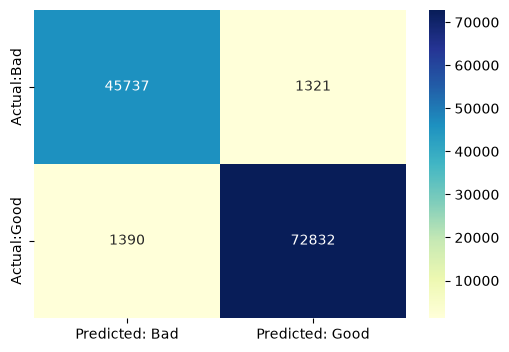

In [61]:
con_mat_xgb = pd.DataFrame(confusion_matrix(y_test.map({'bad': 0, 'good': 1}), xgb_model.predict(x_test)),
columns=['Predicted: Bad', 'Predicted: Good'],
index=['Actual:Bad', 'Actual:Good'])

print('\nCONFUSION MATRIX (XGBoost)')
plt.figure(figsize=(6,4))
sns.heatmap(con_mat_xgb, annot=True, fmt='d', cmap='YlGnBu')


## 11. Random Forest Classifier

In [62]:
rf_model = RandomForestClassifier(n_estimators=150, max_depth=50, min_samples_split=2,
min_samples_leaf=2, random_state=42, n_jobs=-1,
class_weight='balanced')
rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",50
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [63]:
rf_model.score(x_test, y_test)

0.9678842348284961

In [64]:
rf_model.score(x_train, y_train)


0.9768097658713962

In [65]:
print('\nCLASSIFICATION REPORT (Random Forest)\n')
print(classification_report(y_test, rf_model.predict(x_test),
target_names=['Bad', 'Good']))



CLASSIFICATION REPORT (Random Forest)

              precision    recall  f1-score   support

         Bad       0.96      0.95      0.96     47058
        Good       0.97      0.98      0.97     74222

    accuracy                           0.97    121280
   macro avg       0.97      0.97      0.97    121280
weighted avg       0.97      0.97      0.97    121280




CONFUSION MATRIX (Random Forest)


<Axes: >

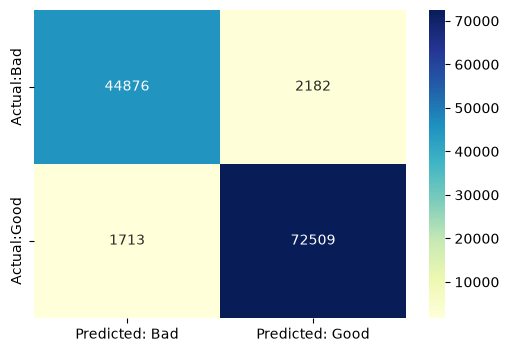

In [66]:
con_mat_rf = pd.DataFrame(confusion_matrix(y_test, rf_model.predict(x_test)),
columns=['Predicted: Bad', 'Predicted: Good'],
index=['Actual:Bad', 'Actual:Good'])

print('\nCONFUSION MATRIX (Random Forest)')
plt.figure(figsize=(6,4))
sns.heatmap(con_mat_rf, annot=True, fmt='d', cmap='YlGnBu')


## 12. Save Models

In [67]:
import pickle

pickle.dump(lr_model, open('phishing_lr.pkl', 'wb'))
pickle.dump(mnb_model, open('phishing_mnb.pkl', 'wb'))
pickle.dump(svm_model, open('phishing_svm.pkl', 'wb'))
pickle.dump(dt_model, open('phishing_dt.pkl', 'wb'))
pickle.dump(xgb_model, open('phishing_xgb.pkl', 'wb'))
pickle.dump(rf_model, open('phishing_rf.pkl', 'wb'))
pickle.dump(tfidf, open('phishing_tfidf.pkl', 'wb'))


In [68]:
predict_bad = [
    'yeniik.com.tr/wp-admin/js/login.alibaba.com/login.jsp.php',
    'fazan-pacir.rs/temp/libraries/ipad',
    'tubemoviez.exe',c
    
]
predict_good = [
    'youtube.com/',
    'youtube.com/watch?v=qI0TQJI3vdU',
    'retailhellunderground.com/',
    'https://nagad.com.bd/',
    'https://www.bkash.com/',
    'https://www.upaybd.com/'
    
    
]

In [69]:
predict_good_X = build_features(predict_good, fit=False)

In [70]:
predict_bad_X = build_features(predict_bad, fit=False)

In [71]:
lr_model.predict(predict_good_X)

array(['good', 'good', 'good', 'bad', 'good', 'bad'], dtype=object)

In [72]:
lr_model.predict(predict_bad_X)

array(['bad', 'bad', 'bad'], dtype=object)

In [73]:
mnb_model.predict(predict_good_X)

array(['good', 'good', 'good', 'bad', 'bad', 'bad'], dtype='<U4')

In [74]:
mnb_model.predict(predict_bad_X)

array(['bad', 'good', 'bad'], dtype='<U4')

In [75]:
svm_model.predict(predict_good_X)

array(['good', 'good', 'good', 'bad', 'good', 'bad'], dtype=object)

In [76]:
svm_model.predict(predict_bad_X)

array(['bad', 'bad', 'bad'], dtype=object)

In [77]:
dt_model.predict(predict_good_X)

array(['good', 'good', 'good', 'bad', 'good', 'bad'], dtype=object)

In [78]:
dt_model.predict(predict_bad_X)

array(['bad', 'bad', 'bad'], dtype=object)

In [79]:
xgb_preds_good = xgb_model.predict(predict_good_X)
xgb_preds_bad = xgb_model.predict(predict_bad_X)

label_map = {0: 'bad', 1: 'good'}
print([label_map[p] for p in xgb_preds_good])
print([label_map[p] for p in xgb_preds_bad])

['good', 'good', 'good', 'bad', 'good', 'bad']
['bad', 'bad', 'bad']


In [80]:
rf_model.predict(predict_good_X)

array(['good', 'good', 'good', 'bad', 'good', 'good'], dtype=object)

In [81]:
rf_model.predict(predict_bad_X)

array(['bad', 'bad', 'bad'], dtype=object)

## 13. Model Comparison

In [82]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM (Linear)', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Test Accuracy': [
        lr_model.score(x_test, y_test),
        mnb_model.score(x_test, y_test),
        svm_model.score(x_test, y_test),
        dt_model.score(x_test, y_test),
        rf_model.score(x_test, y_test),
        xgb_model.score(x_test, y_test.map({'bad': 0, 'good': 1}))
    ]
})
results = results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
results

,Model,Test Accuracy
0,XGBoost,0.977647
1,Random Forest,0.967884
2,Decision Tree,0.962871
3,SVM (Linear),0.956992
4,Logistic Regression,0.954469
5,Naive Bayes,0.894385


## 14. Results Visualization

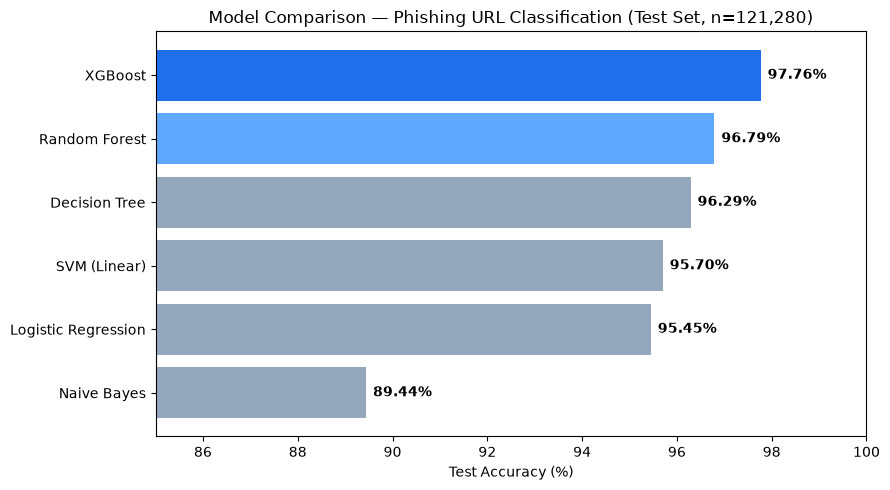

In [83]:
results_sorted = results.sort_values('Test Accuracy', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(results_sorted['Model'], results_sorted['Test Accuracy'] * 100,
                 color=['#94A7BD']*4 + ['#5EA8FF', '#1F6FEB'])
plt.xlabel('Test Accuracy (%)')
plt.title('Model Comparison — Phishing URL Classification (Test Set, n=121,280)')
plt.xlim(85, 100)
for bar, acc in zip(bars, results_sorted['Test Accuracy'] * 100):
    plt.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
              f'{acc:.2f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()


### 14.1 Extended Metrics Table

In [84]:
from sklearn.metrics import classification_report

models_dict = {
    'Logistic Regression': lr_model,
    'Naive Bayes': mnb_model,
    'SVM (Linear)': svm_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
}

def get_metrics(name, model):
    y_true = y_test.map({'bad': 0, 'good': 1}) if name == 'XGBoost' else y_test
    y_pred = model.predict(x_test)
    report = classification_report(y_true, y_pred, target_names=['Bad', 'Good'], output_dict=True)
    return {
        'Model': name,
        'Accuracy': report['accuracy'],
        'Bad Precision': report['Bad']['precision'],
        'Bad Recall': report['Bad']['recall'],
        'Bad F1': report['Bad']['f1-score'],
        'Good Precision': report['Good']['precision'],
        'Good Recall': report['Good']['recall'],
        'Good F1': report['Good']['f1-score'],
        'Macro F1': report['macro avg']['f1-score'],
    }

metrics_df = pd.DataFrame([get_metrics(name, m) for name, m in models_dict.items()])
metrics_df = metrics_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
metrics_df

,Model,Accuracy,Bad Precision,Bad Recall,Bad F1,Good Precision,Good Recall,Good F1,Macro F1
0,XGBoost,0.977647,0.970505,0.971928,0.971216,0.982185,0.981272,0.981729,0.976472
1,Random Forest,0.967884,0.963232,0.953632,0.958408,0.970786,0.976921,0.973844,0.966126
2,Decision Tree,0.962871,0.948051,0.956734,0.952373,0.972409,0.966762,0.969577,0.960975
3,SVM (Linear),0.956992,0.940795,0.948872,0.944816,0.967406,0.962141,0.964766,0.954791
4,Logistic Regression,0.954469,0.937497,0.945705,0.941583,0.965384,0.960025,0.962697,0.952140
5,Naive Bayes,0.894385,0.909413,0.808322,0.855892,0.886474,0.948950,0.916649,0.886271


### 14.2 Grouped Bar Chart — Accuracy, Precision, Recall, F1

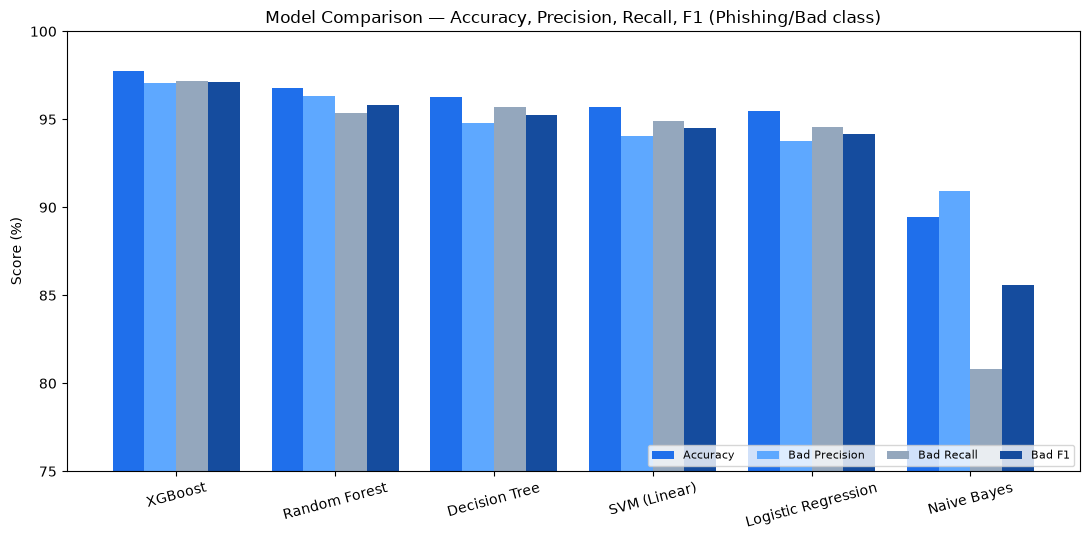

In [85]:
metrics_to_plot = ['Accuracy', 'Bad Precision', 'Bad Recall', 'Bad F1']
x = np.arange(len(metrics_df))
width = 0.2
colors = ['#1F6FEB', '#5EA8FF', '#94A7BD', '#154C9E']

plt.figure(figsize=(11, 5.5))
for i, metric in enumerate(metrics_to_plot):
    plt.bar(x + i*width, metrics_df[metric]*100, width, label=metric, color=colors[i])

plt.xticks(x + width*1.5, metrics_df['Model'], rotation=15)
plt.ylabel('Score (%)')
plt.ylim(75, 100)
plt.title('Model Comparison — Accuracy, Precision, Recall, F1 (Phishing/Bad class)')
plt.legend(loc='lower right', ncol=4, fontsize=8)
plt.tight_layout()
plt.savefig('metrics_grouped_bar.png', dpi=200, bbox_inches='tight')
plt.show()

### 14.3 Radar (Spider) Chart


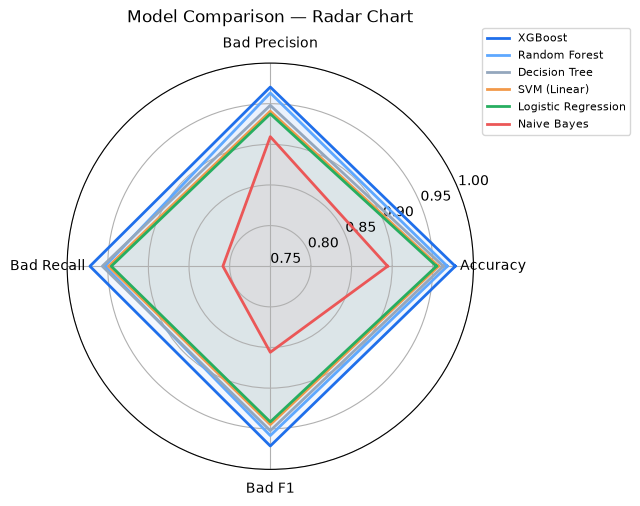

In [86]:
from math import pi

radar_metrics = ['Accuracy', 'Bad Precision', 'Bad Recall', 'Bad F1']
n = len(radar_metrics)
angles = [i / float(n) * 2 * pi for i in range(n)]
angles += angles[:1]
palette = ['#1F6FEB', '#5EA8FF', '#94A7BD', '#F2994A', '#27AE60', '#EB5757']

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for idx, row in metrics_df.iterrows():
    values = row[radar_metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, label=row['Model'], color=palette[idx % len(palette)], linewidth=2)
    ax.fill(angles, values, color=palette[idx % len(palette)], alpha=0.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics)
ax.set_ylim(0.75, 1.0)
plt.title('Model Comparison — Radar Chart', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig('metrics_radar.png', dpi=200, bbox_inches='tight')
plt.show()

### 14.4 Metrics Heatmap


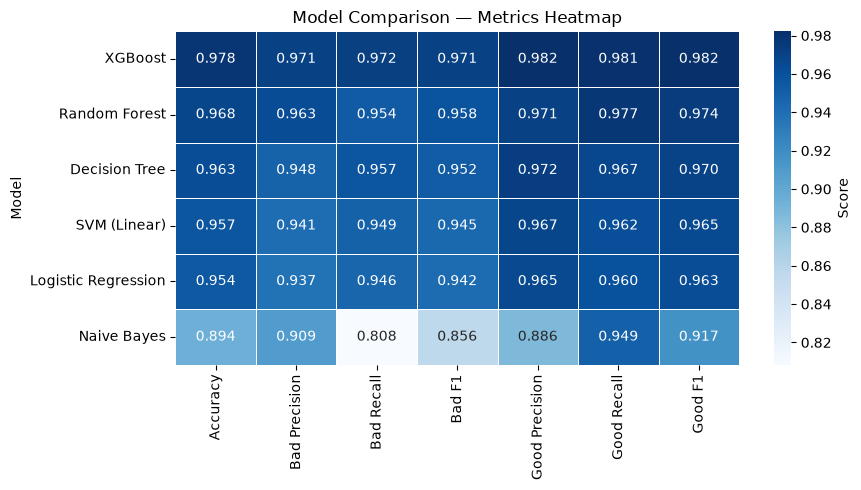

In [87]:
heatmap_data = metrics_df.set_index('Model')[
    ['Accuracy', 'Bad Precision', 'Bad Recall', 'Bad F1', 'Good Precision', 'Good Recall', 'Good F1']
]

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='Blues', linewidths=0.5,
            linecolor='white', cbar_kws={'label': 'Score'})
plt.title('Model Comparison — Metrics Heatmap')
plt.tight_layout()
plt.savefig('metrics_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

### 14.5 ROC Curves (All Models)


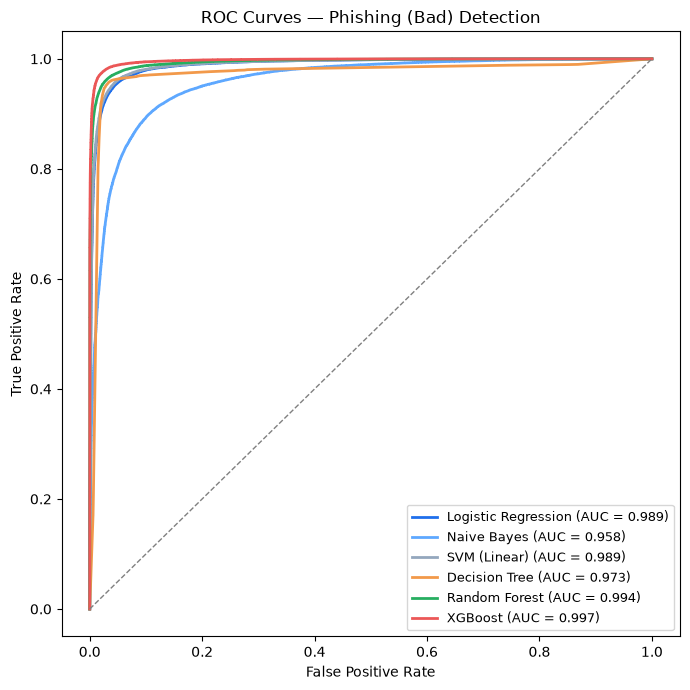

In [88]:
from sklearn.metrics import roc_curve, auc

y_true_bad = (y_test == 'bad').astype(int)  # 1 = phishing (positive class of interest)

def get_bad_score(name, model):
    if name == 'XGBoost':
        return model.predict_proba(x_test)[:, 0]  # class 0 = bad
    if hasattr(model, 'predict_proba'):
        classes = list(model.classes_)
        return model.predict_proba(x_test)[:, classes.index('bad')]
    # LinearSVC has no predict_proba -> use decision_function instead
    scores = model.decision_function(x_test)
    classes = list(model.classes_)
    return -scores if classes[0] == 'bad' else scores

plt.figure(figsize=(7, 7))
for i, (name, model) in enumerate(models_dict.items()):
    score = get_bad_score(name, model)
    fpr, tpr, _ = roc_curve(y_true_bad, score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', color=palette[i], linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Phishing (Bad) Detection')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=200, bbox_inches='tight')
plt.show()

### 14.6 Precision-Recall Curves (All Models)


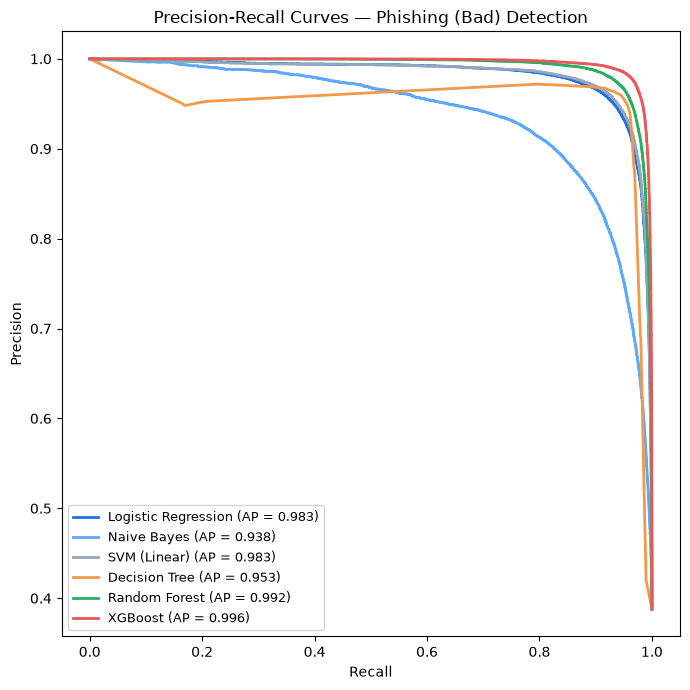

In [89]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7, 7))
for i, (name, model) in enumerate(models_dict.items()):
    score = get_bad_score(name, model)
    precision, recall, _ = precision_recall_curve(y_true_bad, score)
    ap = average_precision_score(y_true_bad, score)
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})', color=palette[i], linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Phishing (Bad) Detection')
plt.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=200, bbox_inches='tight')
plt.show()

### 14.7 Confusion Matrix Grid — All 6 Models (% of Test Set)


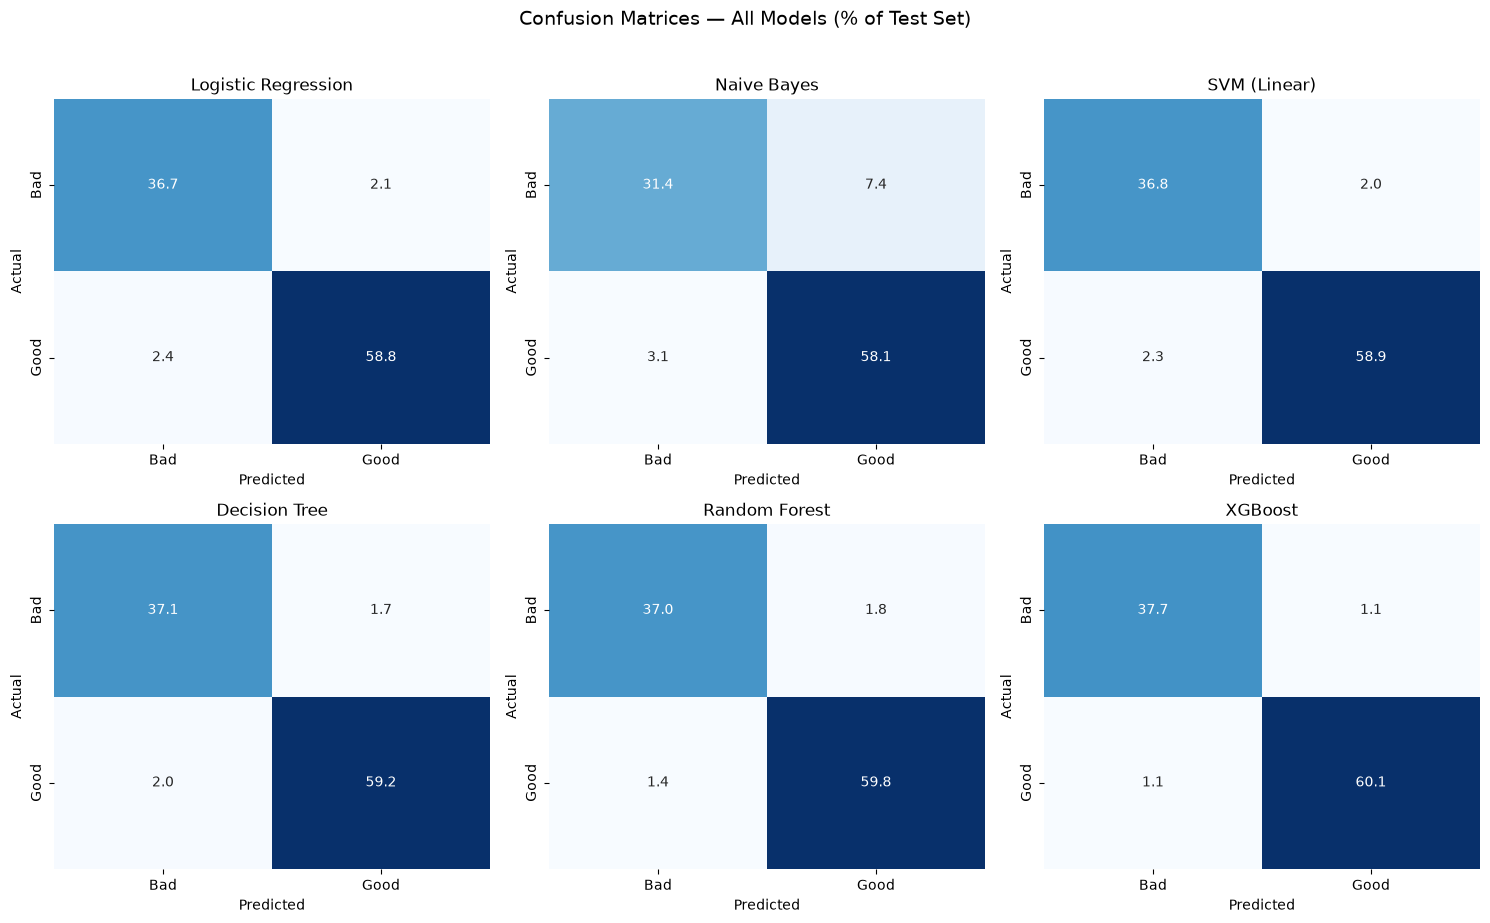

In [90]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, model) in zip(axes.flat, models_dict.items()):
    if name == 'XGBoost':
        y_true, labels = y_test.map({'bad': 0, 'good': 1}), [0, 1]
    else:
        y_true, labels = y_test, ['bad', 'good']
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_pct = cm / cm.sum() * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', cbar=False,
                xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models (% of Test Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix_grid.png', dpi=200, bbox_inches='tight')
plt.show()

### 14.8 Lollipop Chart — Accuracy Ranking


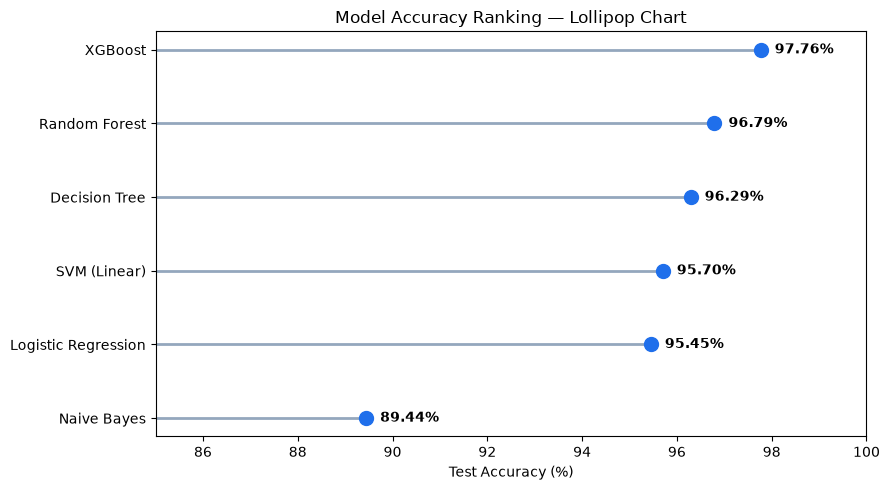

In [91]:
lollipop_df = metrics_df.sort_values('Accuracy')

plt.figure(figsize=(9, 5))
plt.hlines(y=range(len(lollipop_df)), xmin=85, xmax=lollipop_df['Accuracy']*100,
           color='#94A7BD', linewidth=2)
plt.plot(lollipop_df['Accuracy']*100, range(len(lollipop_df)), 'o', color='#1F6FEB', markersize=10)
plt.yticks(range(len(lollipop_df)), lollipop_df['Model'])
for y, xv in zip(range(len(lollipop_df)), lollipop_df['Accuracy']*100):
    plt.text(xv + 0.3, y, f'{xv:.2f}%', va='center', fontweight='bold')
plt.xlim(85, 100)
plt.xlabel('Test Accuracy (%)')
plt.title('Model Accuracy Ranking — Lollipop Chart')
plt.tight_layout()
plt.savefig('accuracy_lollipop.png', dpi=200, bbox_inches='tight')
plt.show()

### 14.9 Error Composition — False Negatives vs. False Positives


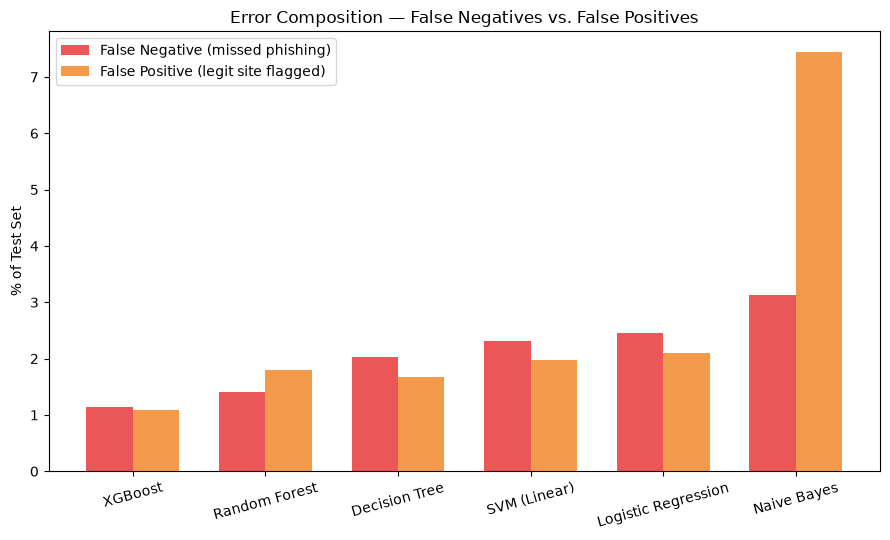

In [92]:
error_rows = []
for name, model in models_dict.items():
    y_true = y_test.map({'bad': 0, 'good': 1}) if name == 'XGBoost' else y_test
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_true, y_pred)  # [[TN, FP], [FN, TP]]
    total = cm.sum()
    error_rows.append({
        'Model': name,
        'False Negative %': cm[1, 0] / total * 100,   # missed phishing
        'False Positive %': cm[0, 1] / total * 100,   # legit flagged
    })

error_df = pd.DataFrame(error_rows).sort_values('False Negative %')
x = np.arange(len(error_df))
width = 0.35

plt.figure(figsize=(9, 5.5))
plt.bar(x - width/2, error_df['False Negative %'], width, label='False Negative (missed phishing)', color='#EB5757')
plt.bar(x + width/2, error_df['False Positive %'], width, label='False Positive (legit site flagged)', color='#F2994A')
plt.xticks(x, error_df['Model'], rotation=15)
plt.ylabel('% of Test Set')
plt.title('Error Composition — False Negatives vs. False Positives')
plt.legend()
plt.tight_layout()
plt.savefig('error_composition.png', dpi=200, bbox_inches='tight')
plt.show()